# Hawkes II：スパイク規模でジャンプ量が変わるモデル

Hawkes Iでは全スパイクの影響を同じ $\gamma$ とした。Hawkes IIでは、閾値超過幅 $x_d$ が大きいほど、その後の発生強度を大きく押し上げる。

$$\gamma_d=\gamma_0\left(1-\exp(-x_d/x_{0,d})\right)$$

$x_{0,d}$ はday $d$までに観測された正のspike magnitudeの平均。観測前強度で $u_d$ の尤度を評価した後、$\gamma_d u_d$ を加える。

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = (
    REPO_ROOT
    / "A_Hawkes_Model_Approach_to_Modeling_Price_Spikes_in_the_Japanese_Electricity_Market"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

AREA = "Tokyo"
TIME_CODE = 15
DATA_DIR = PROJECT_DATA_DIR / "processed"
u_wide = pd.read_csv(
    DATA_DIR / "u_dict" / f"u_{AREA}.csv", index_col=0, parse_dates=True
)
x_wide = pd.read_csv(
    DATA_DIR / "x_dict" / f"x_{AREA}.csv", index_col=0, parse_dates=True
)
data = pd.DataFrame({
    "u": u_wide[str(TIME_CODE)].astype(int),
    "x": x_wide[str(TIME_CODE)].astype(float),
})
data = data.loc["2016-04-01":"2022-03-31"].dropna()
data.describe()

,u,x
count,2191.000000,2191.000000
mean,0.053400,1.561824
std,0.224882,12.168132
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,177.000000


## 強度の計算

$$\lambda_d^-=\alpha\lambda_{d-1}^++\beta,\qquad \lambda_d^+=\lambda_d^-+\gamma_d u_d$$

$$\alpha=\exp(-1/\tau),\qquad\beta=\mu(1-\alpha)$$

In [2]:
EPS = 1e-8


def running_spike_mean(x):
    x = np.asarray(x, float)
    hit = x > 0
    n = np.cumsum(hit)
    total = np.cumsum(x)
    fallback = x[hit].mean() if hit.any() else 1.0
    return np.divide(total, n, out=np.full_like(x, fallback), where=n > 0)


def hawkes2_intensity(u, x, mu, tau, gamma0):
    u = np.asarray(u, int)
    x = np.asarray(x, float)
    alpha = np.exp(-1 / tau)
    beta = mu * (1 - alpha)
    x0 = running_spike_mean(x)
    gamma_d = gamma0 * (1 - np.exp(-x / np.maximum(x0, EPS)))
    pred = np.empty(len(u))
    post = mu
    for d, event in enumerate(u):
        pred[d] = alpha * post + beta
        post = pred[d] + gamma_d[d] * event
    return np.clip(pred, EPS, 1 - EPS), gamma_d


lam_demo, gamma_demo = hawkes2_intensity(data.u, data.x, mu=0.01, tau=5, gamma0=0.3)
pd.DataFrame({
    "u": data.u,
    "x": data.x,
    "gamma_d": gamma_demo,
    "lambda_pred": lam_demo,
}).tail()

,u,x,gamma_d,lambda_pred
date,,,,
2022-03-27,0,0.00,0.000000,0.526949
2022-03-28,0,0.00,0.000000,0.433242
2022-03-29,1,2.24,0.022119,0.356521
2022-03-30,0,0.00,0.000000,0.311817
2022-03-31,0,0.00,0.000000,0.257107


## パラメータ推定

論文は逐次Bayes推定を用いる。ここではモデルの挙動を独立に確認できる基準実装として、弱い正規事前を加えたMAP推定を行う。論文に明記されたモデル式と、実装上の推定器選択を区別する。

In [3]:
def fit_hawkes2(u, x):
    u = np.asarray(u, int)
    x = np.asarray(x, float)
    theta0 = np.log([max(u.mean(), 1e-3), 5.0, 0.2])

    def objective(theta):
        mu, tau, gamma0 = np.exp(theta)
        lam, _ = hawkes2_intensity(u, x, mu, tau, gamma0)
        nll = -np.sum(u * np.log(lam) + (1 - u) * np.log(1 - lam))
        return nll + 0.5 * np.sum(((theta - theta0) / 2) ** 2)

    opt = minimize(
        objective, theta0, method="L-BFGS-B", bounds=[(-9, -0.01), (-4, 6), (-9, -0.01)]
    )
    mu, tau, gamma0 = np.exp(opt.x)
    return {
        "mu": mu,
        "tau": tau,
        "gamma0": gamma0,
        "objective": opt.fun,
        "success": opt.success,
    }


fit2 = fit_hawkes2(data.u, data.x)
fit2

{'mu': 0.003575231124986946,
 'tau': 4.169576321502188,
 'gamma0': 0.4254650674234992,
 'objective': 224.03090643784182,
 'success': True}

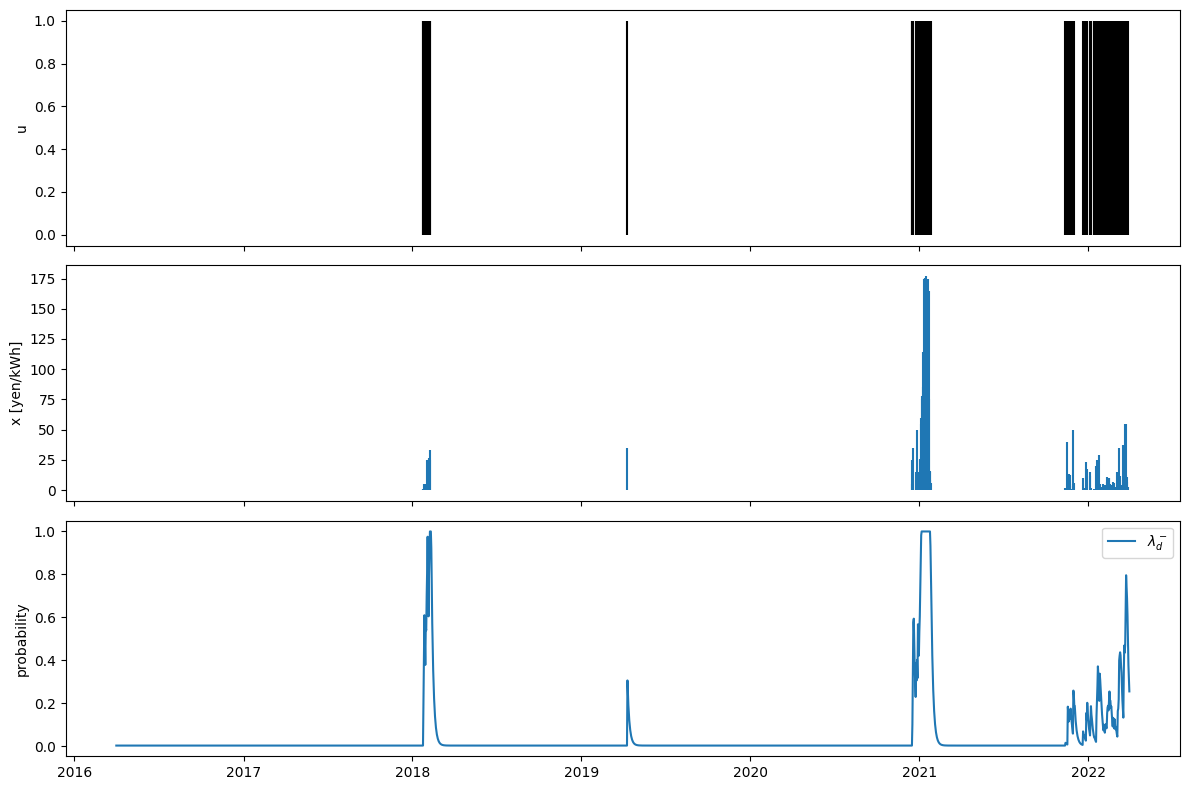

In [4]:
lambda2, gamma2 = hawkes2_intensity(
    data.u, data.x, fit2["mu"], fit2["tau"], fit2["gamma0"]
)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].vlines(data.index[data.u.eq(1)], 0, 1, color="black")
axes[0].set_ylabel("u")
axes[1].vlines(data.index, 0, data.x)
axes[1].set_ylabel("x [yen/kWh]")
axes[2].plot(data.index, lambda2, label=r"$\lambda_d^-$")
axes[2].set_ylabel("probability")
axes[2].legend()
plt.tight_layout()